<a href="https://colab.research.google.com/github/Friskkun/Project-coding-storage/blob/main/Revenge_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

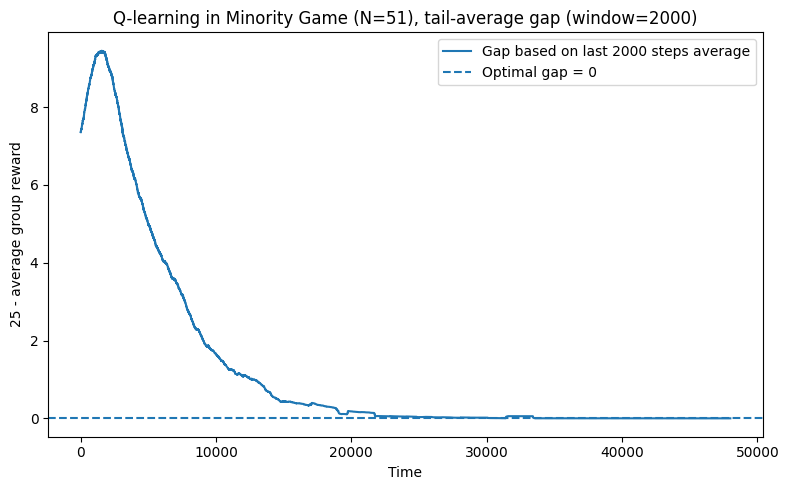

Final average group reward over last 2000 steps: 100.0000
Final gap to optimum: 0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ===== 参数 =====
N = 201
m = 1
T = 50000

alpha = 0.1
gamma = 0.95
epsilon_start = 1.0
epsilon_end = 0.00
epsilon_decay = 0.9997

state_size = 2 ** m
optimal = (N - 1) // 2   # 25
window = 2000            # 改成 2000 就看最后2000次平均


# ===== 工具函数 =====
def encode_history(history):
    x = 0
    for b in history:
        x = (x << 1) | int(b)
    return x


def minority_rewards(actions):
    count_1 = np.sum(actions)
    count_0 = len(actions) - count_1

    rewards = np.zeros(len(actions), dtype=float)

    if count_1 == count_0:
        return rewards

    minority = 1 if count_1 < count_0 else 0
    rewards[actions == minority] = 1.0
    return rewards


# ===== 初始化 =====
Q_tables = np.zeros((N, state_size, 2), dtype=float)
history = np.random.randint(0, 2, size=m)
epsilon = epsilon_start

group_rewards = []   # 每一轮“瞬时”的群体总收益


# ===== 主循环 =====
for t in range(T):
    s = encode_history(history)

    actions = np.zeros(N, dtype=int)

    # 选动作
    for i in range(N):
        if np.random.rand() < epsilon:
            actions[i] = np.random.randint(0, 2)
        else:
            actions[i] = np.argmax(Q_tables[i, s])

    # 奖励
    rewards = minority_rewards(actions)
    total_reward_t = np.sum(rewards)
    group_rewards.append(total_reward_t)

    # 更新公共历史
    count_1 = np.sum(actions)
    count_0 = N - count_1

    if count_1 == count_0:
        minority = np.random.randint(0, 2)   # N=51不会发生，只是保险
    else:
        minority = 1 if count_1 < count_0 else 0

    history = np.roll(history, -1)
    history[-1] = minority

    s_next = encode_history(history)

    # Q-learning 更新
    for i in range(N):
        a = actions[i]
        r = rewards[i]
        Q_tables[i, s, a] += alpha * (
            r + gamma * np.max(Q_tables[i, s_next]) - Q_tables[i, s, a]
        )

    # epsilon 衰减
    epsilon = max(epsilon_end, epsilon * epsilon_decay)


# ===== 计算“最近 window 步平均群体收益”的 gap =====
group_rewards = np.array(group_rewards)

avg_group_reward = np.convolve(
    group_rewards,
    np.ones(window) / window,
    mode='valid'
)

gap_tail = optimal - avg_group_reward


# ===== 画图 =====
plt.figure(figsize=(8, 5))
plt.plot(gap_tail, label=f"Gap based on last {window} steps average")
plt.axhline(0, linestyle='--', label="Optimal gap = 0")
plt.xlabel("Time")
plt.ylabel("25 - average group reward")
plt.title(f"Q-learning in Minority Game (N=51), tail-average gap (window={window})")
plt.legend()
plt.tight_layout()
plt.show()


# ===== 输出最后一段的平均结果 =====
print(f"Final average group reward over last {window} steps: {avg_group_reward[-1]:.4f}")
print(f"Final gap to optimum: {gap_tail[-1]:.4f}")

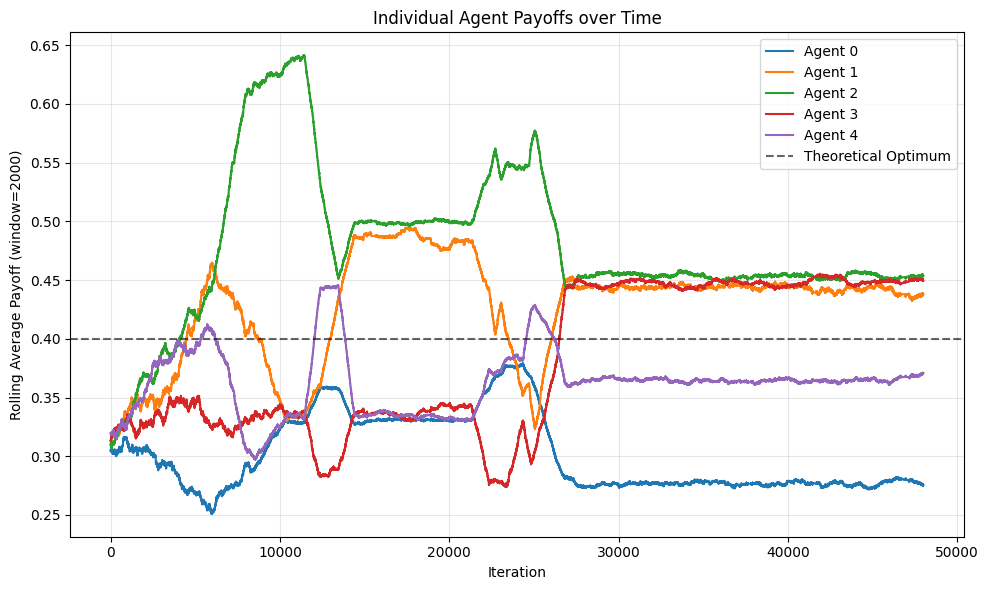

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 参数 =====
N = 5
m = 5
T = 50000

alpha = 0.1
gamma = 0.95
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.9997

state_size = 2 ** m
optimal_per_agent = ((N - 1) / 2) / N  # Average expected payoff per agent at global optimum
window = 2000

# ===== 工具函数 =====
def encode_history(history):
    x = 0
    for b in history:
        x = (x << 1) | int(b)
    return x

def minority_rewards(actions):
    count_1 = np.sum(actions)
    count_0 = len(actions) - count_1
    rewards = np.zeros(len(actions), dtype=float)
    if count_1 == count_0:
        return rewards
    minority = 1 if count_1 < count_0 else 0
    rewards[actions == minority] = 1.0
    return rewards

# ===== 初始化 =====
Q_tables = np.zeros((N, state_size, 2), dtype=float)
history = np.random.randint(0, 2, size=m)
epsilon = epsilon_start

# --- NEW: Track rewards for each individual agent ---
agent_rewards_history = np.zeros((T, N))

# ===== 主循环 =====
for t in range(T):
    s = encode_history(history)
    actions = np.zeros(N, dtype=int)

    for i in range(N):
        if np.random.rand() < epsilon:
            actions[i] = np.random.randint(0, 2)
        else:
            actions[i] = np.argmax(Q_tables[i, s])

    rewards = minority_rewards(actions)

    # --- NEW: Store rewards for each agent ---
    agent_rewards_history[t, :] = rewards

    count_1 = np.sum(actions)
    count_0 = N - count_1
    minority = 1 if count_1 < count_0 else 0 if count_1 > count_0 else np.random.randint(0, 2)

    history = np.roll(history, -1)
    history[-1] = minority
    s_next = encode_history(history)

    for i in range(N):
        a = actions[i]
        r = rewards[i]
        Q_tables[i, s, a] += alpha * (
            r + gamma * np.max(Q_tables[i, s_next]) - Q_tables[i, s, a]
        )

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

# ===== 计算滚动平均 =====
plt.figure(figsize=(10, 6))

for i in range(N):
    # Calculate rolling mean for agent i
    rolling_avg = np.convolve(
        agent_rewards_history[:, i],
        np.ones(window) / window,
        mode='valid'
    )
    plt.plot(rolling_avg, label=f"Agent {i}")

plt.axhline(optimal_per_agent, color='black', linestyle='--', alpha=0.6, label="Theoretical Optimum")
plt.xlabel("Iteration")
plt.ylabel(f"Rolling Average Payoff (window={window})")
plt.title("Individual Agent Payoffs over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

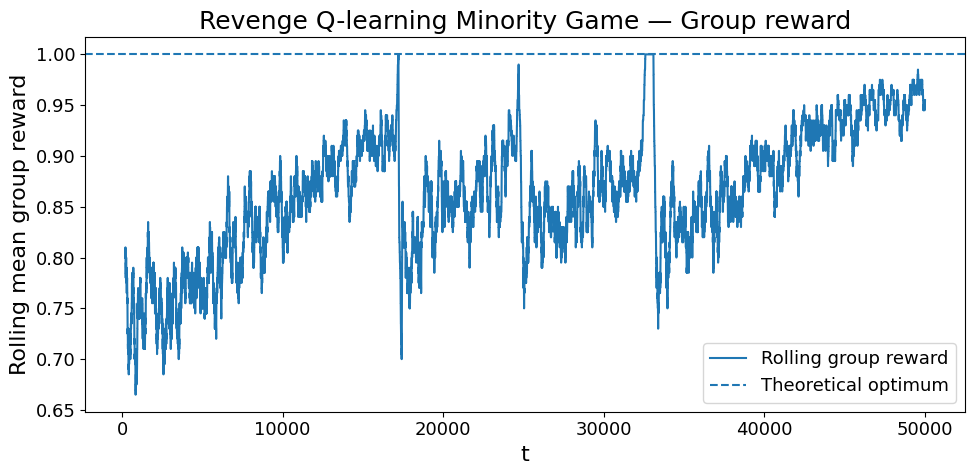

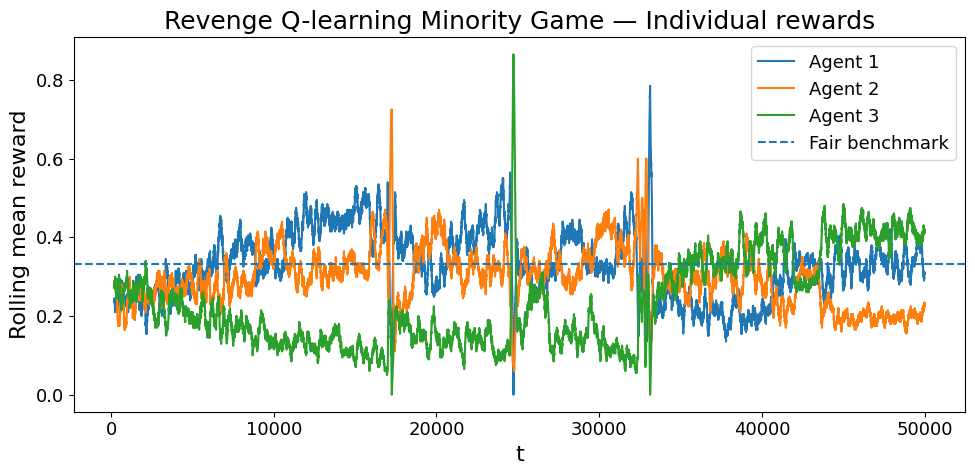

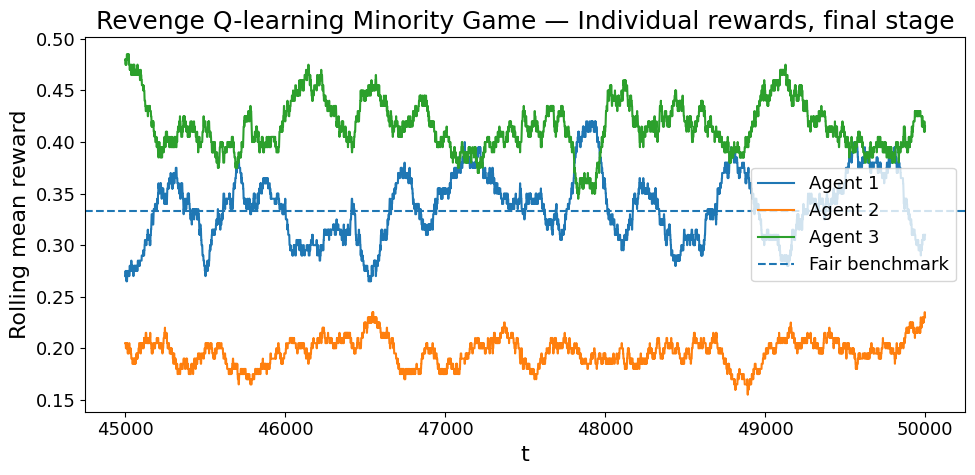

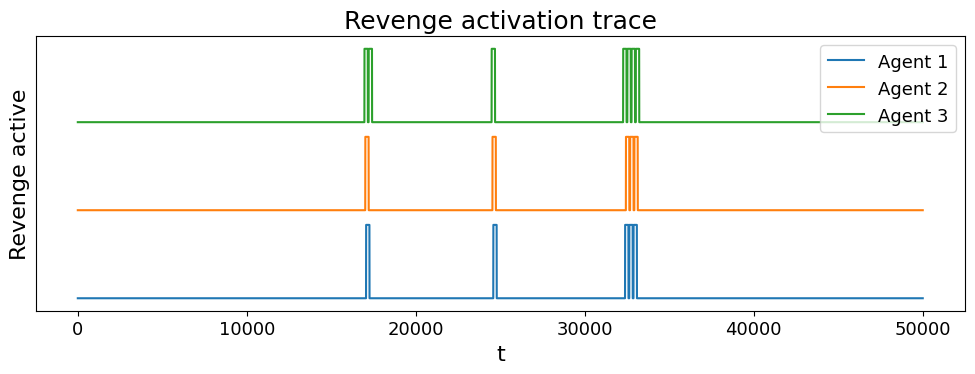

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# Plot settings
# --------------------------------------------------

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})


# --------------------------------------------------
# Helper function: encode public history
# --------------------------------------------------

def encode_history(history):
    """
    Convert binary history list into decimal state index.
    Example: [1,0,1] -> 5
    """
    s = 0
    for b in history:
        s = (s << 1) | int(b)
    return s


# --------------------------------------------------
# Q-learning agent with revenge mechanism
# --------------------------------------------------

class RevengeQAgent:
    def __init__(
        self,
        n_states,
        alpha=0.05,
        gamma=0.99,
        eps_start=1.0,
        eps_end=0.01,
        eps_decay=0.999,
        trigger_window=20,
        revenge_len=30,
        eps_reset=0.5,
        rng=None
    ):
        self.Q = np.zeros((n_states, 2))

        self.alpha = alpha
        self.gamma = gamma

        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.eps_reset = eps_reset

        self.trigger_window = trigger_window
        self.revenge_len = revenge_len

        self.zero_streak = 0
        self.in_revenge = False
        self.revenge_left = 0
        self.revenge_action = None

        self.rng = rng if rng is not None else np.random.default_rng()

    def choose_action(self, state):
        """
        If in revenge phase, keep choosing the fixed revenge action.
        Otherwise use epsilon-greedy Q-learning policy.
        """
        if self.in_revenge:
            return self.revenge_action, False

        if self.rng.random() < self.eps:
            action = self.rng.integers(0, 2)
        else:
            max_q = np.max(self.Q[state])
            best_actions = np.flatnonzero(self.Q[state] == max_q)
            action = self.rng.choice(best_actions)

        return action, True

    def update_q(self, state, action, reward, next_state):
        """
        Standard Q-learning update.
        """
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error

    def update_revenge_status(self, reward):
        """
        Check whether revenge should be triggered or ended.
        """
        if self.in_revenge:
            self.revenge_left -= 1

            if self.revenge_left <= 0:
                self.in_revenge = False
                self.revenge_action = None
                self.zero_streak = 0

                # Reset exploration after revenge
                self.eps = max(self.eps, self.eps_reset)

            return

        # Normal phase: track consecutive zero rewards
        if reward == 0:
            self.zero_streak += 1
        else:
            self.zero_streak = 0

        # Trigger revenge
        if self.zero_streak >= self.trigger_window:
            self.in_revenge = True
            self.revenge_left = self.revenge_len
            self.revenge_action = self.rng.integers(0, 2)
            self.zero_streak = 0

    def decay_epsilon(self):
        """
        Decay epsilon only during normal learning phase.
        """
        if not self.in_revenge:
            self.eps = max(self.eps_end, self.eps * self.eps_decay)


# --------------------------------------------------
# Minority Game with revenge Q-learning
# --------------------------------------------------

def run_minority_game_revenge_qlearning(
    N=3,
    m=3,
    T=50000,
    alpha=0.05,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.999,
    trigger_window=20,
    revenge_len=30,
    eps_reset=0.5,
    seed=42
):
    assert N % 2 == 1, "N should be odd for the standard Minority Game."

    rng = np.random.default_rng(seed)
    n_states = 2 ** m

    agents = [
        RevengeQAgent(
            n_states=n_states,
            alpha=alpha,
            gamma=gamma,
            eps_start=eps_start,
            eps_end=eps_end,
            eps_decay=eps_decay,
            trigger_window=trigger_window,
            revenge_len=revenge_len,
            eps_reset=eps_reset,
            rng=np.random.default_rng(seed + i + 1)
        )
        for i in range(N)
    ]

    # Initial public history
    history = list(rng.integers(0, 2, size=m))

    rewards_trace = np.zeros((T, N))
    actions_trace = np.zeros((T, N), dtype=int)
    group_rewards = np.zeros(T)
    revenge_trace = np.zeros((T, N), dtype=int)
    eps_trace = np.zeros((T, N))

    for t in range(T):
        state = encode_history(history)

        actions = np.zeros(N, dtype=int)
        update_allowed = np.zeros(N, dtype=bool)

        # Agents choose actions
        for i, agent in enumerate(agents):
            action, can_update = agent.choose_action(state)
            actions[i] = action
            update_allowed[i] = can_update
            revenge_trace[t, i] = int(agent.in_revenge)
            eps_trace[t, i] = agent.eps

        # Determine minority action
        count_0 = np.sum(actions == 0)
        count_1 = np.sum(actions == 1)

        if count_0 < count_1:
            minority_action = 0
        else:
            minority_action = 1

        rewards = (actions == minority_action).astype(int)

        # Update public history
        next_history = history[1:] + [minority_action]
        next_state = encode_history(next_history)

        # Q-learning update
        for i, agent in enumerate(agents):
            if update_allowed[i]:
                agent.update_q(state, actions[i], rewards[i], next_state)

        # Update revenge status and epsilon
        for i, agent in enumerate(agents):
            agent.update_revenge_status(rewards[i])
            agent.decay_epsilon()

        # Store traces
        rewards_trace[t] = rewards
        actions_trace[t] = actions
        group_rewards[t] = np.sum(rewards)

        history = next_history

    return {
        "rewards_trace": rewards_trace,
        "actions_trace": actions_trace,
        "group_rewards": group_rewards,
        "revenge_trace": revenge_trace,
        "eps_trace": eps_trace,
    }


# --------------------------------------------------
# Run experiment
# --------------------------------------------------

out = run_minority_game_revenge_qlearning(
    N=3,
    m=3,
    T=50000,
    alpha=0.05,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.9999,
    trigger_window=50,
    revenge_len=200,
    eps_reset=0.5,
    seed=42
)

rewards_trace = out["rewards_trace"]
group_rewards = out["group_rewards"]
revenge_trace = out["revenge_trace"]

T = rewards_trace.shape[0]
N = rewards_trace.shape[1]


# --------------------------------------------------
# Figure 1: rolling mean total utility
# --------------------------------------------------

window = 200
kernel = np.ones(window) / window

rolling_group = np.convolve(group_rewards, kernel, mode="valid")
t_roll = np.arange(window - 1, T)

plt.figure(figsize=(10, 5))
plt.plot(t_roll, rolling_group, label="Rolling group reward")
plt.axhline((N - 1) / 2, linestyle="--", label="Theoretical optimum")
plt.xlabel("t")
plt.ylabel(f"Rolling mean group reward")
plt.title("Revenge Q-learning Minority Game — Group reward")
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Figure 2: rolling mean reward of each agent
# Similar style to your Figure 4
# --------------------------------------------------

plt.figure(figsize=(10, 5))

for i in range(N):
    roll_i = np.convolve(rewards_trace[:, i], kernel, mode="valid")
    plt.plot(t_roll, roll_i, label=f"Agent {i+1}")

plt.axhline((N - 1) / (2 * N), linestyle="--", label="Fair benchmark")
plt.xlabel("t")
plt.ylabel(f"Rolling mean reward")
plt.title("Revenge Q-learning Minority Game — Individual rewards")
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Figure 3: zoom into the last part
# --------------------------------------------------

tail = 5000

plt.figure(figsize=(10, 5))

for i in range(N):
    roll_i = np.convolve(rewards_trace[:, i], kernel, mode="valid")
    plt.plot(t_roll[-tail:], roll_i[-tail:], label=f"Agent {i+1}")

plt.axhline((N - 1) / (2 * N), linestyle="--", label="Fair benchmark")
plt.xlabel("t")
plt.ylabel(f"Rolling mean reward")
plt.title("Revenge Q-learning Minority Game — Individual rewards, final stage")
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Figure 4: show when revenge is active
# --------------------------------------------------

plt.figure(figsize=(10, 4))

for i in range(N):
    plt.plot(revenge_trace[:, i] + i * 1.2, label=f"Agent {i+1}")

plt.xlabel("t")
plt.ylabel("Revenge active")
plt.title("Revenge activation trace")
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()